In [6]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf

In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# image size and paths
IMG_SIZE = (155, 220)   # typical CEDAR signature crop
CHANNELS = 1
DATA_DIR = "dataset"

In [10]:
import re
def get_signature_paths(data_dir):
    """Returns dict mapping writer_id → {'org': [...], 'forg': [...]}"""
    writers = {}
    for folder, key in [('full_org', 'org'), ('full_forg', 'forg')]:
        folder_path = os.path.join(data_dir, folder)
        for fname in os.listdir(folder_path):
            path = os.path.join(folder_path, fname)
            # skip non-files
            if not os.path.isfile(path):
                continue
            # split on "_" and expect: prefix_writer_index.ext
            parts = fname.split('_')
            if len(parts) < 3:
                continue  # unexpected name
            try:
                writer_id = int(parts[1])
            except ValueError:
                continue
            writers.setdefault(writer_id, {'org': [], 'forg': []})
            writers[writer_id][key].append(path)
    return writers

# Usage
writers = get_signature_paths(DATA_DIR)
all_writers = sorted(writers.keys())
random.shuffle(all_writers)

train_w = all_writers[:40]
val_w   = all_writers[40:48]
test_w  = all_writers[48:]
print(f"Train writers: {len(train_w)}, Val: {len(val_w)}, Test: {len(test_w)}")
print(train_w)

Train writers: 40, Val: 8, Test: 7
[31, 24, 50, 12, 17, 21, 51, 54, 36, 20, 10, 34, 42, 45, 30, 55, 4, 22, 47, 5, 29, 11, 43, 23, 39, 25, 1, 26, 52, 19, 32, 37, 27, 13, 40, 33, 49, 14, 46, 53]


In [11]:
def make_balanced_triplet_dataset(
    writers_dict,
    writer_ids,
    num_samples,
    batch_size=32,
    shuffle_writers=True,
    seed=SEED
):
    """Returns a tf.data.Dataset of ((A,P,N), label) with balanced writers."""
    
    # 1) base dataset of writer IDs, repeated and shuffled
    ds = tf.data.Dataset.from_tensor_slices(writer_ids)
    ds = ds.repeat()  # infinite
    if shuffle_writers:
        ds = ds.shuffle(buffer_size=len(writer_ids), seed=seed)
    ds = ds.take(num_samples)
    
    # 2) map writer ID → one triplet
    def _sample_and_load(w):
        # w is a scalar tf.Tensor holding the writer_id
        def _py_sample(w_int):
            # sample 2 genuine + 1 forg from that writer
            orgs = writers_dict[int(w_int)]['org']
            forgs = writers_dict[int(w_int)]['forg']
            a, p = random.sample(orgs, 2)
            n    = random.choice(forgs)
            return a, p, n
        
        a_path, p_path, n_path = tf.py_function(
            func=_py_sample,
            inp=[w],
            Tout=[tf.string, tf.string, tf.string]
        )
        # set shapes for downstream
        for t in (a_path, p_path, n_path):
            t.set_shape(())
        
        # load + preprocess images
        def _load(path):
            img = tf.io.read_file(path)
            img = tf.image.decode_png(img, channels=1)
            img = tf.image.resize(img, IMG_SIZE) / 255.0
            img.set_shape(IMG_SIZE + (1,))  # Explicit shape setting
            return img
        
        A = _load(a_path)
        P = _load(p_path)
        N = _load(n_path)
        
        # dummy label (unused in triplet loss)
        label = tf.constant(0.0, dtype=tf.float32)
        return (A, P, N), label
    
    ds = ds.map(_sample_and_load, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [12]:
NUM_TRAIN_SAMPLES = 2
NUM_VAL_SAMPLES   = 2

train_ds = make_balanced_triplet_dataset(
    writers, train_w,
    num_samples=NUM_TRAIN_SAMPLES,
    batch_size=32,
)
val_ds = make_balanced_triplet_dataset(
    writers, val_w,
    num_samples=NUM_VAL_SAMPLES,
    batch_size=32,
)

Dummy label (unused in triplet loss): 0.0


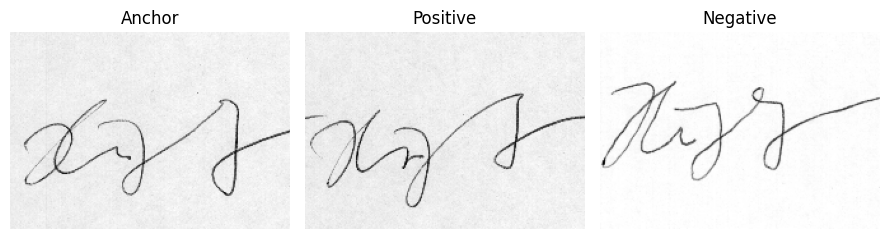

In [20]:
import matplotlib.pyplot as plt

# Take one batch from the dataset
for (A, P, N), label in train_ds.take(1):
    # Convert the first triplet to NumPy arrays
    anchor_img   = A[0].numpy().squeeze()  # shape: (H, W)
    positive_img = P[0].numpy().squeeze()
    negative_img = N[0].numpy().squeeze()
    triplet_label = label[0].numpy()

    print(f"Dummy label (unused in triplet loss): {triplet_label}")

    # Plot the three images side by side
    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(anchor_img, cmap='gray')
    plt.title("Anchor")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(positive_img, cmap='gray')
    plt.title("Positive")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(negative_img, cmap='gray')
    plt.title("Negative")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    break